# Lesson 3A: DBSCAN Theory — Density-Based Clustering

## Introduction

K-Means assumes spherical clusters. Hierarchical works but is slow. What if clusters are arbitrary shapes? What if there's noise?

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) answers both:
- Finds **arbitrary cluster shapes** (moons, rings, spirals)
- **Identifies noise points** (outliers that don't belong)
- **No K required upfront** — density tells you
- **Fast**: O(n log n) with spatial indexing

Core insight: Points in dense regions form clusters. Points in sparse regions are noise.

In this lesson:
1. Understand density concepts: epsilon, minpts, core points
2. Learn density-reachability and density-connectivity
3. Implement DBSCAN from scratch
4. Visualize clusters and noise
5. Compare with K-Means and Hierarchical on non-convex data

## Table of Contents

1. [Introduction](#introduction)
2. [Required Libraries](#required-libraries)
3. [Density Concepts](#density)
4. [Epsilon-Neighborhoods](#epsilon)
5. [Core and Border Points](#core-border)
6. [Density-Reachability](#reachability)
7. [From-Scratch DBSCAN](#scratch)
8. [Scikit-learn Validation](#sklearn)
9. [Non-Convex Data](#nonconvex)
10. [Comparison with K-Means](#comparison)
11. [Noise and Outliers](#noise)
12. [Conclusion](#conclusion)

<a name="required-libraries"></a>
## Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform, euclidean, cdist
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from typing import Tuple
from numpy.typing import NDArray

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("✅ Libraries loaded!")

✅ Libraries loaded!


<a name="density"></a>
## Density Concepts

### The Core Idea

DBSCAN groups points that are close to many neighbors. A point with few neighbors nearby is **noise**.

Two hyperparameters control density:
1. **epsilon (ε)**: Radius of neighborhood around a point
2. **minpts**: Minimum number of points needed in ε-neighborhood to be "dense"

<a name="epsilon"></a>
## Epsilon-Neighborhoods

The **ε-neighborhood** of point $p$ is the set of all points within distance ε from $p$:

$$N_\epsilon(p) = \{q : d(p, q) \leq \epsilon\}$$

### Key Insight

The size of $N_\epsilon(p)$ tells you about density:
- **$|N_\epsilon(p)| \geq \text{minpts}$**: Point $p$ is in a dense region (candidate core point)
- **$|N_\epsilon(p)| < \text{minpts}$**: Point $p$ is in sparse region (potential noise)

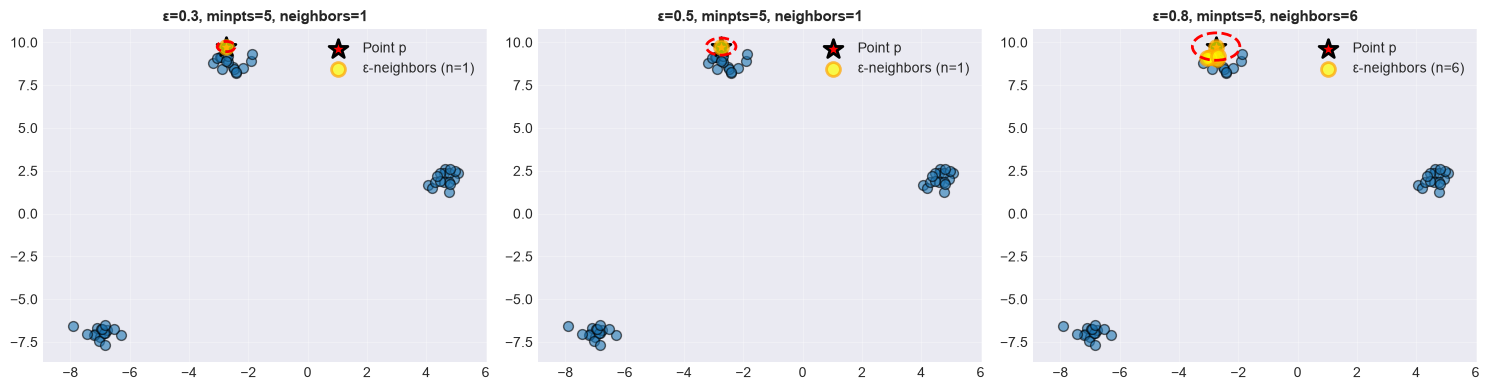

💡 Larger ε → more neighbors in each neighborhood


In [2]:
# Visualize epsilon-neighborhoods
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=50, centers=3, n_features=2, cluster_std=0.4, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

eps_values = [0.3, 0.5, 0.8]

for idx, eps in enumerate(eps_values):
    ax = axes[idx]
    
    # Plot all points
    ax.scatter(X[:, 0], X[:, 1], s=50, alpha=0.6, edgecolors='k')
    
    # Highlight first point and its epsilon-neighborhood
    p = X[0]
    neighbors = cdist([p], X)[0] <= eps
    
    ax.scatter(p[0], p[1], s=200, c='red', marker='*', edgecolors='black', linewidth=2, label='Point p')
    ax.scatter(X[neighbors, 0], X[neighbors, 1], s=100, c='yellow', alpha=0.7, edgecolors='orange', linewidth=2, label=f'ε-neighbors (n={neighbors.sum()})')
    
    # Draw epsilon circle
    circle = plt.Circle(p, eps, fill=False, edgecolor='red', linestyle='--', linewidth=2)
    ax.add_patch(circle)
    
    ax.set_title(f'ε={eps}, minpts=5, neighbors={neighbors.sum()}', fontsize=11, fontweight='bold')
    ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
    ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Larger ε → more neighbors in each neighborhood")

<a name="core-border"></a>
## Core and Border Points

### Core Point
A point $p$ is **core** if:
$$|N_\epsilon(p)| \geq \text{minpts}$$

Core points are centers of clusters — they're in dense regions.

### Border Point
A point $q$ is **border** if:
- It's NOT a core point
- It's in the ε-neighborhood of some core point $p$

### Noise Point
A point is **noise** if it's neither core nor border.

### Visualization

/tmp/user/1003/ipykernel_1970240/1393409273.py:29: UserWarning: You passed an edgecolor/edgecolors ('darkred') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  scatter3 = ax.scatter(X[noise_mask, 0], X[noise_mask, 1], s=100, c='red', marker='x',


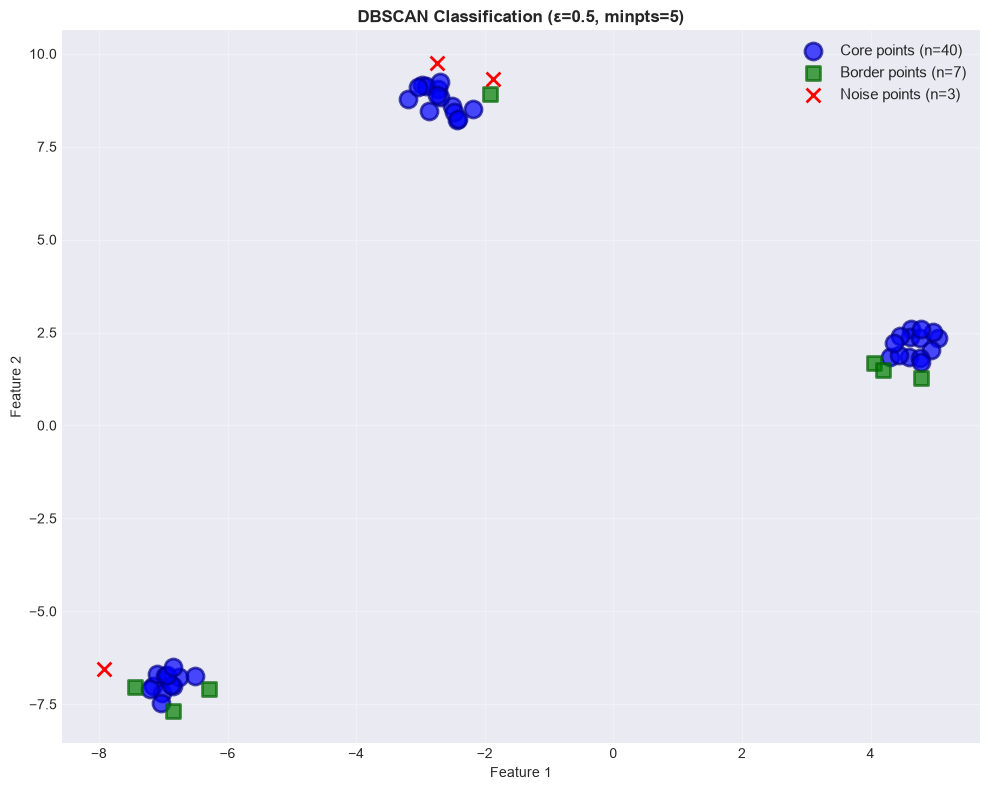

Classification: 40 core, 7 border, 3 noise


In [3]:
# Classify points as core, border, or noise
eps = 0.5
minpts = 5

# Find core points
distances = cdist(X, X)
neighbors_count = (distances <= eps).sum(axis=1)
core_mask = neighbors_count >= minpts

# Find border points
border_mask = np.zeros(len(X), dtype=bool)
for i in range(len(X)):
    if not core_mask[i]:  # Not core
        for j in range(len(X)):
            if core_mask[j] and distances[i, j] <= eps:
                border_mask[i] = True
                break

# Noise points
noise_mask = ~(core_mask | border_mask)

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))

scatter1 = ax.scatter(X[core_mask, 0], X[core_mask, 1], s=150, c='blue', marker='o', 
                     edgecolors='darkblue', linewidth=2, label=f'Core points (n={core_mask.sum()})', alpha=0.7)
scatter2 = ax.scatter(X[border_mask, 0], X[border_mask, 1], s=100, c='green', marker='s',
                     edgecolors='darkgreen', linewidth=2, label=f'Border points (n={border_mask.sum()})', alpha=0.7)
scatter3 = ax.scatter(X[noise_mask, 0], X[noise_mask, 1], s=100, c='red', marker='x',
                     edgecolors='darkred', linewidth=2, label=f'Noise points (n={noise_mask.sum()})')

ax.set_title(f'DBSCAN Classification (ε={eps}, minpts={minpts})', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Classification: {core_mask.sum()} core, {border_mask.sum()} border, {noise_mask.sum()} noise")

<a name="scratch"></a>
## From-Scratch DBSCAN Implementation

In [4]:
def dbscan_scratch(X: NDArray, eps: float, minpts: int) -> Tuple[NDArray, list]:
    """
    DBSCAN clustering from scratch.
    
    Returns:
        labels: Cluster assignment (-1 for noise)
        clusters: List of core point indices for each cluster
    """
    n_samples = X.shape[0]
    labels = np.full(n_samples, -1)  # -1 = noise by default
    
    # Compute all pairwise distances
    distances = cdist(X, X)
    
    # Find neighbors for each point
    neighbors = [np.where(distances[i] <= eps)[0] for i in range(n_samples)]
    
    # Find core points
    core_points = np.where([len(n) >= minpts for n in neighbors])[0]
    
    # Cluster core points
    cluster_id = 0
    visited = np.zeros(n_samples, dtype=bool)
    
    for p in core_points:
        if visited[p]:
            continue
        
        # Start new cluster
        queue = [p]
        visited[p] = True
        labels[p] = cluster_id
        
        # Expand cluster
        while queue:
            point = queue.pop(0)
            
            # Add all neighbors of core points
            for neighbor in neighbors[point]:
                if not visited[neighbor]:
                    visited[neighbor] = True
                    labels[neighbor] = cluster_id
                    
                    # If neighbor is also core, expand further
                    if len(neighbors[neighbor]) >= minpts:
                        queue.append(neighbor)
        
        cluster_id += 1
    
    return labels, core_points

# Test
labels_scratch, core_pts = dbscan_scratch(X, eps=0.5, minpts=5)

print(f"From-scratch DBSCAN:")
print(f"  Clusters: {len(np.unique(labels_scratch[labels_scratch >= 0]))}")
print(f"  Noise points: {(labels_scratch == -1).sum()}")

From-scratch DBSCAN:
  Clusters: 3
  Noise points: 3


<a name="sklearn"></a>
## Scikit-learn Validation

In [5]:
# Scikit-learn DBSCAN
dbscan_sk = DBSCAN(eps=0.5, min_samples=5)
labels_sk = dbscan_sk.fit_predict(X)

print(f"Scikit-learn DBSCAN:")
print(f"  Clusters: {len(np.unique(labels_sk[labels_sk >= 0]))}")
print(f"  Noise points: {(labels_sk == -1).sum()}")

print(f"\nMatch: {np.allclose(np.sort(np.unique(labels_scratch)), np.sort(np.unique(labels_sk)))}")

Scikit-learn DBSCAN:
  Clusters: 3
  Noise points: 3

Match: True


<a name="nonconvex"></a>
## DBSCAN on Non-Convex Data

The power of DBSCAN: it finds arbitrary shapes that K-Means and Hierarchical miss.

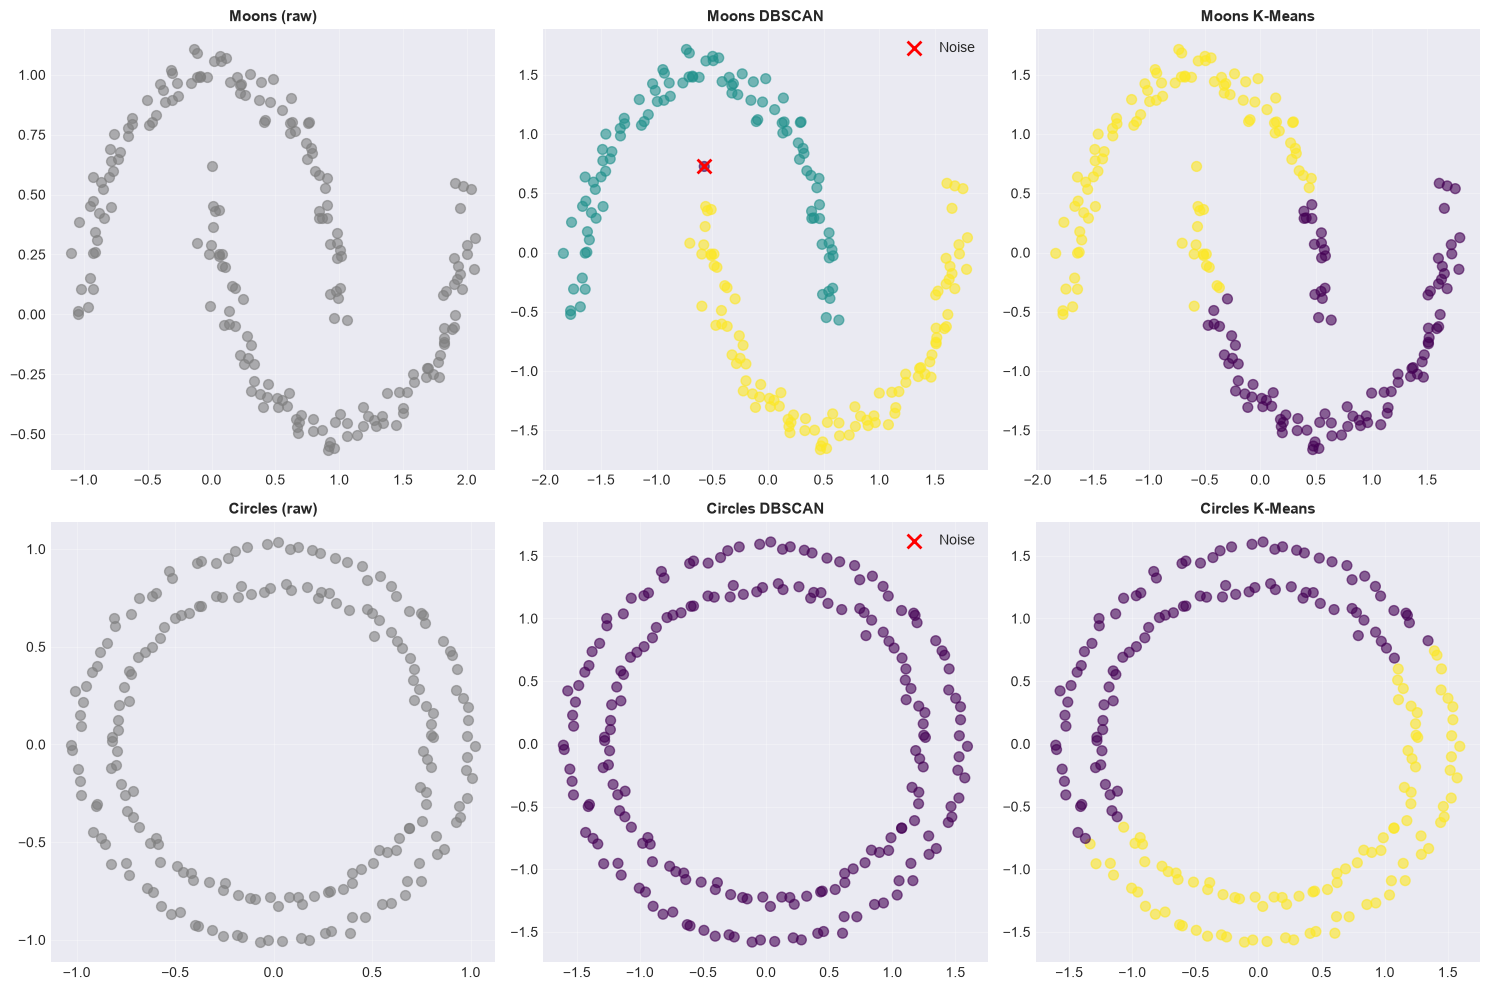

💡 DBSCAN finds moons and circles; K-Means creates linear boundaries


In [6]:
# Generate non-convex datasets
moons, _ = make_moons(n_samples=200, noise=0.05, random_state=42)
circles, _ = make_circles(n_samples=200, noise=0.02, random_state=42)

datasets = [('Moons', moons), ('Circles', circles)]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for row, (name, data) in enumerate(datasets):
    data_scaled = StandardScaler().fit_transform(data)
    
    # DBSCAN
    dbscan = DBSCAN(eps=0.3, min_samples=5)
    labels_dbscan = dbscan.fit_predict(data_scaled)
    
    # K-Means (for comparison)
    from sklearn.cluster import KMeans
    kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
    labels_kmeans = kmeans.fit_predict(data_scaled)
    
    # Plot original data
    ax = axes[row, 0]
    ax.scatter(data[:, 0], data[:, 1], c='gray', s=50, alpha=0.6)
    ax.set_title(f'{name} (raw)', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Plot DBSCAN
    ax = axes[row, 1]
    scatter = ax.scatter(data_scaled[:, 0], data_scaled[:, 1], c=labels_dbscan, cmap='viridis', s=50, alpha=0.6)
    noise_mask = labels_dbscan == -1
    ax.scatter(data_scaled[noise_mask, 0], data_scaled[noise_mask, 1], c='red', marker='x', s=100, linewidth=2, label='Noise')
    ax.set_title(f'{name} DBSCAN', fontsize=11, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Plot K-Means (for comparison)
    ax = axes[row, 2]
    scatter = ax.scatter(data_scaled[:, 0], data_scaled[:, 1], c=labels_kmeans, cmap='viridis', s=50, alpha=0.6)
    ax.set_title(f'{name} K-Means', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 DBSCAN finds moons and circles; K-Means creates linear boundaries")

<a name="conclusion"></a>
## Conclusion

### Key Takeaways

1. **DBSCAN finds arbitrary cluster shapes** — not limited to spheres/blobs
2. **Identifies noise automatically** — doesn't force all points into clusters
3. **No K required** — density defines clusters
4. **Two hyperparameters** — epsilon (ε) and minpts control density threshold
5. **Trade-off: parameter sensitivity** — choosing ε and minpts is harder than choosing K

### When to Use DBSCAN

- ✅ Non-convex cluster shapes
- ✅ Variable-density clusters
- ✅ Outlier detection important
- ❌ High-dimensional data (curse of dimensionality)
- ❌ When all points must be in a cluster

### Next Steps

In Lesson 3B (practical), we'll:
- Choose ε using k-distance graphs
- Apply DBSCAN to real data
- Introduce HDBSCAN (hierarchical DBSCAN)
- Benchmark against K-Means and Hierarchical

You now understand the three major clustering paradigms:
1. **K-Means**: Fast, spherical, fixed K
2. **Hierarchical**: Interpretable, dendrograms, slower
3. **DBSCAN**: Arbitrary shapes, noise detection, parameter-sensitive

Choose wisely based on your data! 🎯